# EDA — Grupos de Galaxias por Historia Evolutiva

Análisis exploratorio de los cuatro grupos de galaxias clasificados por historial de fusiones y actividad AGN:

| Grupo | Fusión | AGN | Simulación |
|-------|--------|-----|------------|
| A | ✓ | ✓ | RefL0100N1504 |
| B | ✗ | ✓ | RefL0100N1504 |
| C | ✓ | ✗ | NoAGNL0050N0752 |
| D | ✗ | ✗ | NoAGNL0050N0752 |


## Imports, paleta y carga de datos

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ─── Paleta y estilo ──────────────────────────────────────────────────────────
COLORS = {
    'A': '#E63946',   # rojo  — AGN + Merger
    'B': '#457B9D',   # azul  — AGN + NoMerger
    'C': '#F4A261',   # naranja — NoAGN + Merger
    'D': '#2A9D8F',   # verde  — NoAGN + NoMerger
}
LABELS = {
    'A': 'A: Merger + AGN',
    'B': 'B: No Merger + AGN',
    'C': 'C: Merger + NoAGN',
    'D': 'D: No Merger + NoAGN',
}
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.edgecolor':   '#CCCCCC',
    'axes.grid':        True,
    'grid.color':       '#E0E0E0',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'legend.fontsize':  10,
})

# ─── Carga de datos ───────────────────────────────────────────────────────────
BASE = 'data/'
dfs = {
    'A': pd.read_csv(BASE + 'AGN_Merger_A.csv'),
    'B': pd.read_csv(BASE + 'AGN_NoMerger_B.csv'),
    'C': pd.read_csv(BASE + 'NoAGN_Merger_C.csv'),
    'D': pd.read_csv(BASE + 'NoAGN_NoMerger_D.csv'),
}

# Añadir columna de grupo y unificar
for g, df in dfs.items():
    df['Grupo'] = g
    
# Pedimos que haya al menos 10 galaxias por combinación de Delta_Snap y Grupo para incluirla en el análisis
df = df.groupby(['Delta_Snap', 'Grupo']).filter(lambda x: len(x) >= 10)


# Variables con/sin uniformización disponibles por grupo
VARS_UNIF  = ['12+log(O/H)_unif', 'Fgas_unif', 'log_Mstar_unif']
VARS_ABS   = ['12+log(O/H)', 'Fgas', 'log_Mstar']
VAR_BH     = 'log_MBH_Mstar'       # disponible sólo en A y B
VAR_BH_U   = 'log_MBH_Mstar_unif'

In [22]:
dfs = {
    nombre: df.groupby(['Delta_Snap', 'Grupo'])
              .filter(lambda x: len(x) >= 10)
    for nombre, df in dfs.items()
}

In [23]:
print("=== Resumen de muestras ===")
for g, df in dfs.items():
    ngal = df['RootGalaxyID'].nunique()
    nrow = len(df)
    snaps = f"{df['Delta_Snap'].min()} → {df['Delta_Snap'].max()}"
    print(f"  Grupo {g} ({LABELS[g]}): {ngal} galaxias, {nrow} filas, Delta_Snap {snaps}")

=== Resumen de muestras ===
  Grupo A (A: Merger + AGN): 393 galaxias, 4922 filas, Delta_Snap -2 → 14
  Grupo B (B: No Merger + AGN): 339 galaxias, 4030 filas, Delta_Snap -2.0 → 12.0
  Grupo C (C: Merger + NoAGN): 78 galaxias, 916 filas, Delta_Snap -2 → 12
  Grupo D (D: No Merger + NoAGN): 60 galaxias, 769 filas, Delta_Snap -2 → 12


In [7]:
dfs['A']

,RootGalaxyID,GalaxyID,SnapNum,Snap_Major_Merger,Delta_Snap,Delta_Time_Gyr,12+log(O/H)_unif,Fgas_unif,log_Mstar_unif,log_MBH_Mstar_unif,12+log(O/H),Fgas,log_Mstar,log_MBH_Mstar,Grupo
0,8694639,8694646,21,23,-2,1.47,0.000000,0.000000,0.000000,0.000000,8.802193,0.442821,9.687214,-3.322667,A
1,8694639,8694645,22,23,-1,0.76,0.046559,-0.037037,0.119085,0.068994,8.848752,0.405784,9.806299,-3.253672,A
2,8694639,8694644,23,23,0,0.00,0.081197,-0.071540,0.423805,-0.138992,8.883390,0.371281,10.111019,-3.461659,A
3,8694639,8694643,24,23,1,-1.10,0.199539,-0.164542,0.541712,-0.130987,9.001732,0.278279,10.228926,-3.453653,A
4,8694639,8694642,25,23,2,-1.98,0.236204,-0.207000,0.612661,-0.118327,9.038397,0.235821,10.299875,-3.440993,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5050,21986361,21986365,24,17,7,-5.37,-0.036266,-0.229570,0.737640,-0.021071,8.897018,0.019337,11.905013,-2.865155,A
5051,21986361,21986364,25,17,8,-6.25,-0.028687,-0.233685,0.793942,-0.042115,8.904597,0.015222,11.961315,-2.886199,A
5052,21986361,21986363,26,17,9,-7.17,-0.020591,-0.238436,0.846791,-0.235304,8.912693,0.010471,12.014164,-3.079388,A
5053,21986361,21986362,27,17,10,-8.14,0.014946,-0.236574,0.880279,0.233542,8.948230,0.012333,12.047652,-2.610542,A


## Figura 1 — Descripción de las muestras

In [24]:
# FIGURA 1 — Resumen de tamaños de muestra y cobertura temporal

## Figura 2 — Distribuciones KDE por grupo (Delta_Snap = 0)

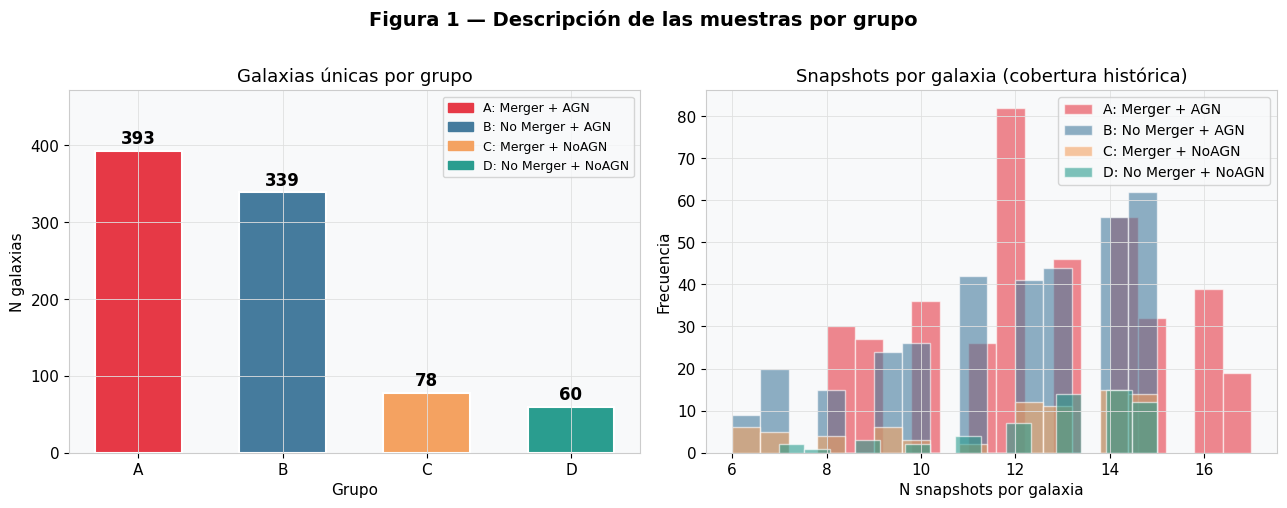

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Figura 1 — Descripción de las muestras por grupo", fontsize=14, fontweight='bold', y=1.01)

# 1a: Galaxias únicas por grupo
ngals = {g: dfs[g]['RootGalaxyID'].nunique() for g in 'ABCD'}
ax = axes[0]
bars = ax.bar(list(ngals.keys()), list(ngals.values()),
              color=[COLORS[g] for g in 'ABCD'], edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, ngals.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title("Galaxias únicas por grupo")
ax.set_xlabel("Grupo")
ax.set_ylabel("N galaxias")
ax.set_ylim(0, max(ngals.values()) * 1.2)
handles = [plt.Rectangle((0,0),1,1, color=COLORS[g]) for g in 'ABCD']
ax.legend(handles, [LABELS[g] for g in 'ABCD'], loc='upper right', fontsize=9)

# 1b: Distribución de cobertura temporal (snaps por galaxia)
ax = axes[1]
for g in 'ABCD':
    snaps_per_gal = dfs[g].groupby('RootGalaxyID')['Delta_Snap'].count()
    ax.hist(snaps_per_gal, bins=15, alpha=0.6, color=COLORS[g], label=LABELS[g], edgecolor='white')
ax.set_title("Snapshots por galaxia (cobertura histórica)")
ax.set_xlabel("N snapshots por galaxia")
ax.set_ylabel("Frecuencia")
ax.legend()

plt.tight_layout()
#plt.savefig('/home/claude/fig1_muestras.png', dpi=150, bbox_inches='tight')
#plt.close()
#print("Fig 1 guardada")

## Figura 3 — Boxplots comparativos entre grupos

In [26]:
# FIGURA 2 — Distribuciones de variables absolutas por grupo (KDE + hist)

## Figura 4 — Evolución temporal de variables uniformizadas

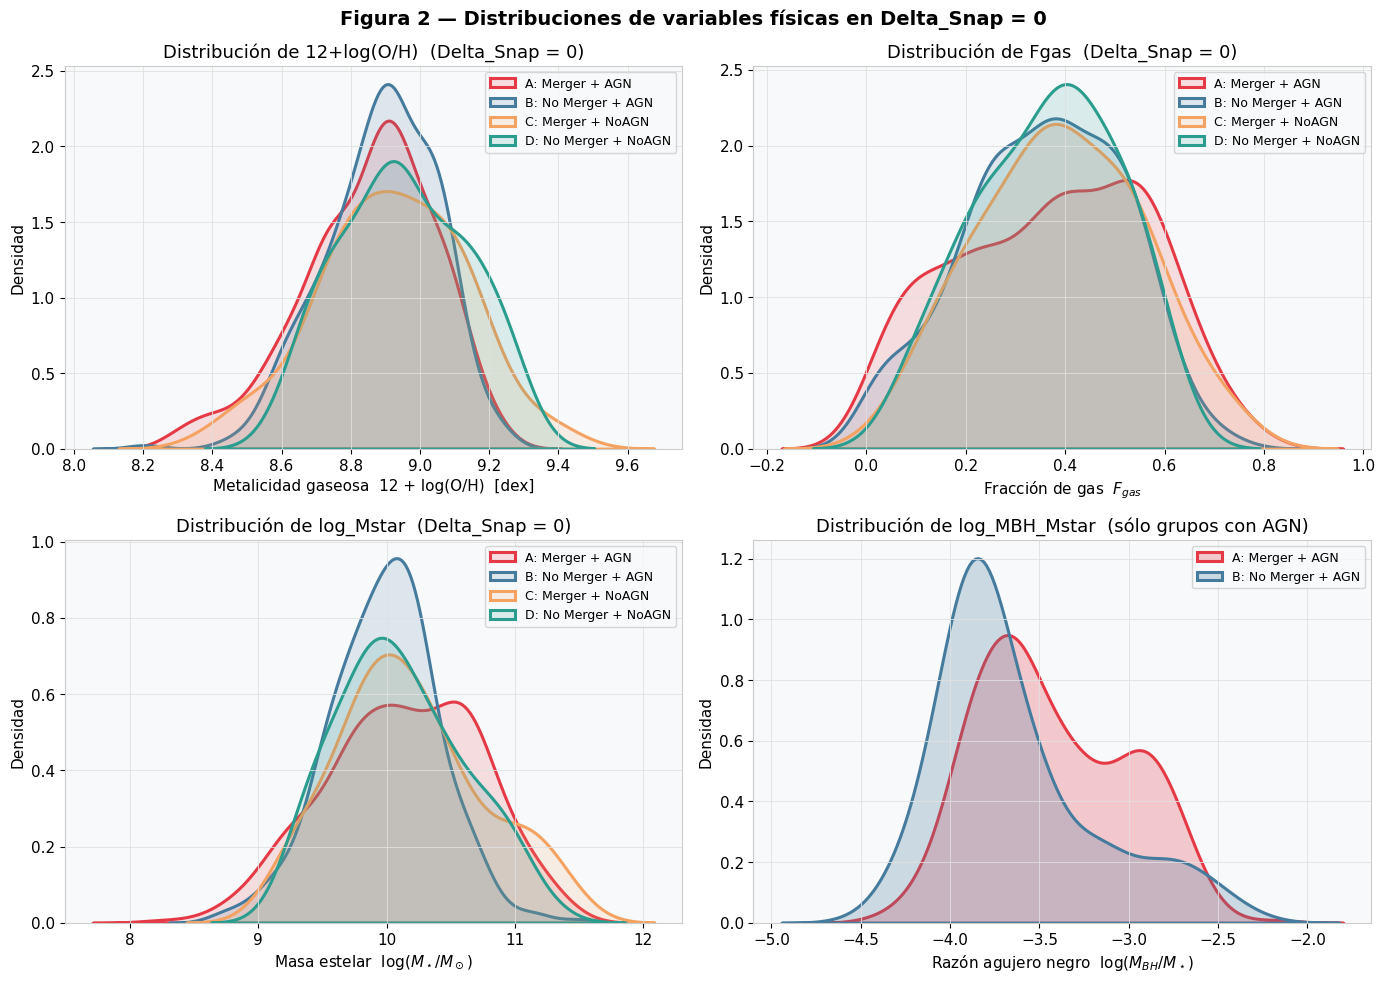

In [25]:
snap_ref = 0   # estado en el momento del merger/referencia

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Figura 2 — Distribuciones de variables físicas en Delta_Snap = 0", fontsize=14, fontweight='bold')

plot_vars = [
    ('12+log(O/H)', 'Metalicidad gaseosa  12 + log(O/H)  [dex]'),
    ('Fgas',        'Fracción de gas  $F_{gas}$'),
    ('log_Mstar',   'Masa estelar  log($M_\\star / M_\\odot$)'),
]

# Para MBH sólo A y B
for ax_idx, (var, xlabel) in enumerate(plot_vars):
    ax = axes[ax_idx // 2][ax_idx % 2]
    for g in 'ABCD':
        df_snap = dfs[g][dfs[g]['Delta_Snap'] == snap_ref]
        if var in df_snap.columns and df_snap[var].notna().sum() > 5:
            sns.kdeplot(df_snap[var].dropna(), ax=ax, color=COLORS[g],
                        label=LABELS[g], linewidth=2.2, fill=True, alpha=0.15)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Densidad")
    ax.set_title(f"Distribución de {var}  (Delta_Snap = 0)")
    ax.legend(fontsize=9)

# Panel 4: MBH sólo A y B
ax = axes[1][1]
for g in ['A', 'B']:
    df_snap = dfs[g][dfs[g]['Delta_Snap'] == snap_ref]
    if VAR_BH in df_snap.columns and df_snap[VAR_BH].notna().sum() > 5:
        sns.kdeplot(df_snap[VAR_BH].dropna(), ax=ax, color=COLORS[g],
                    label=LABELS[g], linewidth=2.2, fill=True, alpha=0.25)
ax.set_xlabel('Razón agujero negro  log($M_{BH}/M_\\star$)')
ax.set_ylabel("Densidad")
ax.set_title("Distribución de log_MBH_Mstar  (sólo grupos con AGN)")
ax.legend(fontsize=9)

plt.tight_layout()
#plt.savefig('/home/claude/fig2_distribuciones.png', dpi=150, bbox_inches='tight')
#plt.close()
#print("Fig 2 guardada")

## Figura 5 — Matrices de correlación de Spearman

In [28]:
# FIGURA 3 — Boxplots comparativos entre grupos (snapshot 0)

## Figura 6 — Relación masa-metalicidad (MZR)

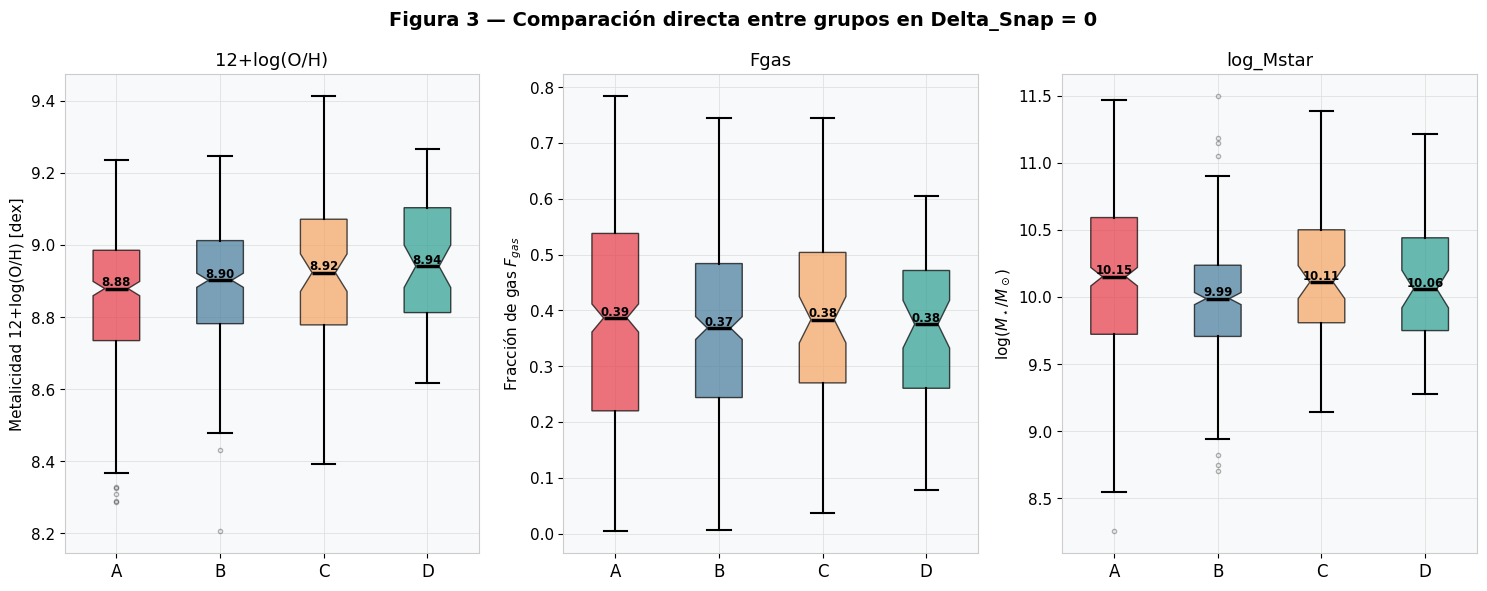

In [26]:
snap0_list = []
for g in 'ABCD':
    df_snap = dfs[g][dfs[g]['Delta_Snap'] == 0].copy()
    df_snap['Grupo'] = g
    snap0_list.append(df_snap)
df_snap0 = pd.concat(snap0_list, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle("Figura 3 — Comparación directa entre grupos en Delta_Snap = 0", fontsize=14, fontweight='bold')

bvars = [
    ('12+log(O/H)', 'Metalicidad 12+log(O/H) [dex]'),
    ('Fgas',        'Fracción de gas $F_{gas}$'),
    ('log_Mstar',   'log($M_\\star / M_\\odot$)'),
]
for ax, (var, ylabel) in zip(axes, bvars):
    data_plot = df_snap0[['Grupo', var]].dropna()
    bp = ax.boxplot(
        [data_plot[data_plot['Grupo'] == g][var].values for g in 'ABCD'],
        patch_artist=True, notch=True, vert=True,
        medianprops=dict(color='black', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=3, alpha=0.3),
    )
    for patch, g in zip(bp['boxes'], 'ABCD'):
        patch.set_facecolor(COLORS[g])
        patch.set_alpha(0.7)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(['A', 'B', 'C', 'D'], fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{var}")
    # Anotación de mediana
    for i, g in enumerate('ABCD'):
        vals = data_plot[data_plot['Grupo'] == g][var].dropna()
        if len(vals) > 0:
            med = np.median(vals)
            ax.text(i+1, med, f'{med:.2f}', ha='center', va='bottom',
                    fontsize=8.5, color='black', fontweight='bold')

plt.tight_layout()
#plt.savefig('/home/claude/fig3_boxplots.png', dpi=150, bbox_inches='tight')
#plt.close()
#print("Fig 3 guardada")

## Figura 7 — Evolución central de Δ12+log(O/H)

In [30]:
# FIGURA 4 — Evolución temporal de variables uniformizadas (Delta_unif vs Delta_Snap)

## Figura 8 — Pair plot Grupo A (pre vs post merger)

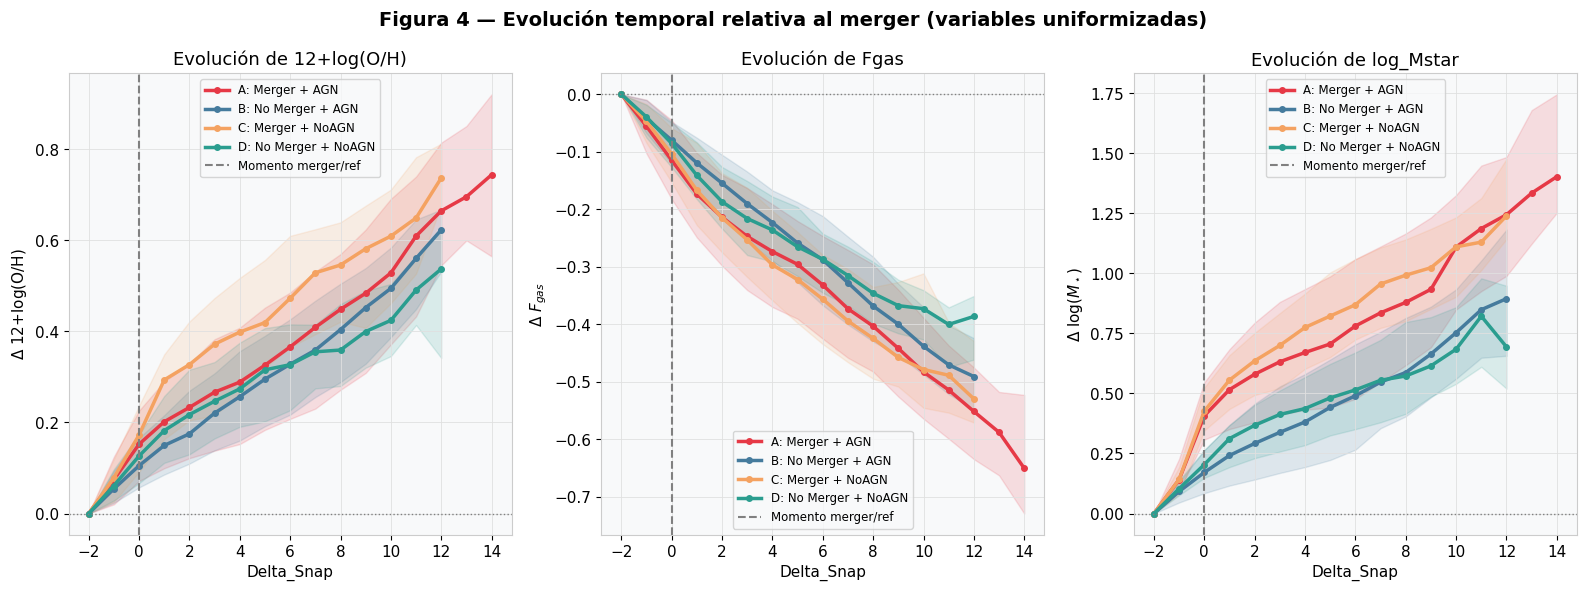

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Figura 4 — Evolución temporal relativa al merger (variables uniformizadas)", fontsize=14, fontweight='bold')

evol_vars = [
    ('12+log(O/H)_unif', r'$\Delta$ 12+log(O/H)'),
    ('Fgas_unif',         r'$\Delta$ $F_{gas}$'),
    ('log_Mstar_unif',    r'$\Delta$ log($M_\star$)'),
]

var_temporal = 'Delta_Snap' # 'Delta_Snap'

for ax, (var, ylabel) in zip(axes, evol_vars):
    for g in 'ABCD':
        if var not in dfs[g].columns:
            continue
        df_g = dfs[g][[var_temporal, var]].dropna()
        # Mediana por Delta_Snap
        med = df_g.groupby(var_temporal)[var].median()
        q25 = df_g.groupby(var_temporal)[var].quantile(0.25)
        q75 = df_g.groupby(var_temporal)[var].quantile(0.75)
        ax.plot(med.index, med.values, color=COLORS[g], label=LABELS[g],
                linewidth=2.5, marker='o', markersize=4)
        ax.fill_between(med.index, q25.values, q75.values,
                        color=COLORS[g], alpha=0.15)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1.5, label='Momento merger/ref')
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel("Delta_Snap")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Evolución de {var.replace('_unif','')}")
    ax.legend(fontsize=8.5)

plt.tight_layout()
#plt.savefig('/home/claude/fig4_evolucion_temporal.png', dpi=150, bbox_inches='tight')
#plt.close()
#print("Fig 4 guardada")

In [28]:
dfs['C'][(dfs['C']['Delta_Snap'] == 12)]

,RootGalaxyID,GalaxyID,SnapNum,Snap_Major_Merger,Delta_Snap,Delta_Time_Gyr,Stars_Mass,Fgas,12+log(O/H),Stars_Mass_pre_merger,12+log(O/H)_pre_merger,Fgas_pre_merger,log_Mstar,12+log(O/H)_unif,Fgas_unif,log_Mstar_unif,Grupo
49,3154894,3154895,27,15,12,-9.19,3.881207e+10,0.172998,9.137998,9.447112e+08,8.365712,0.478628,10.588967,0.772286,-0.305630,1.613668,C
124,3498031,3498032,27,15,12,-9.19,1.201545e+10,0.146754,9.131484,5.441284e+08,8.280171,0.780955,10.079740,0.851313,-0.634202,1.344039,C
223,3447594,3447594,28,16,12,-10.05,2.432670e+10,0.080084,9.251275,1.755026e+09,8.499027,0.654988,10.386083,0.752249,-0.574905,1.141800,C
278,3641574,3641575,27,15,12,-9.19,1.014821e+10,0.149931,9.134132,7.108648e+08,8.413301,0.511729,10.006389,0.720830,-0.361798,1.154602,C
344,3542571,3542571,28,16,12,-10.05,2.318788e+10,0.129933,9.165161,6.563710e+08,8.389553,0.689285,10.365261,0.775608,-0.559352,1.548112,C
359,2263810,2263812,26,14,12,-8.55,2.065777e+11,0.037864,9.310687,1.497002e+10,9.065336,0.407252,11.315083,0.245350,-0.369388,1.139861,C
486,2687121,2687121,28,16,12,-10.05,1.180832e+11,0.043521,9.335274,3.565482e+09,8.510173,0.684080,11.072188,0.825101,-0.640559,1.520070,C
570,2862337,2862337,28,16,12,-10.05,1.023822e+11,0.044369,9.418585,5.746381e+09,8.716841,0.531190,11.010224,0.701744,-0.486820,1.250830,C
585,2881789,2881789,28,16,12,-10.05,9.049202e+10,0.017337,9.532153,6.527559e+09,8.708244,0.577421,10.956610,0.823909,-0.560084,1.141859,C
626,2957873,2957874,27,15,12,-9.19,3.618872e+10,0.187219,9.076655,2.141056e+09,8.421314,0.730973,10.558573,0.655341,-0.543754,1.227945,C


## Tabla resumen y tests estadísticos (Kruskal-Wallis + Mann-Whitney)

In [ ]:
# FIGURA 5 — Correlaciones entre variables (heatmap por grupo)

## Bloque 10

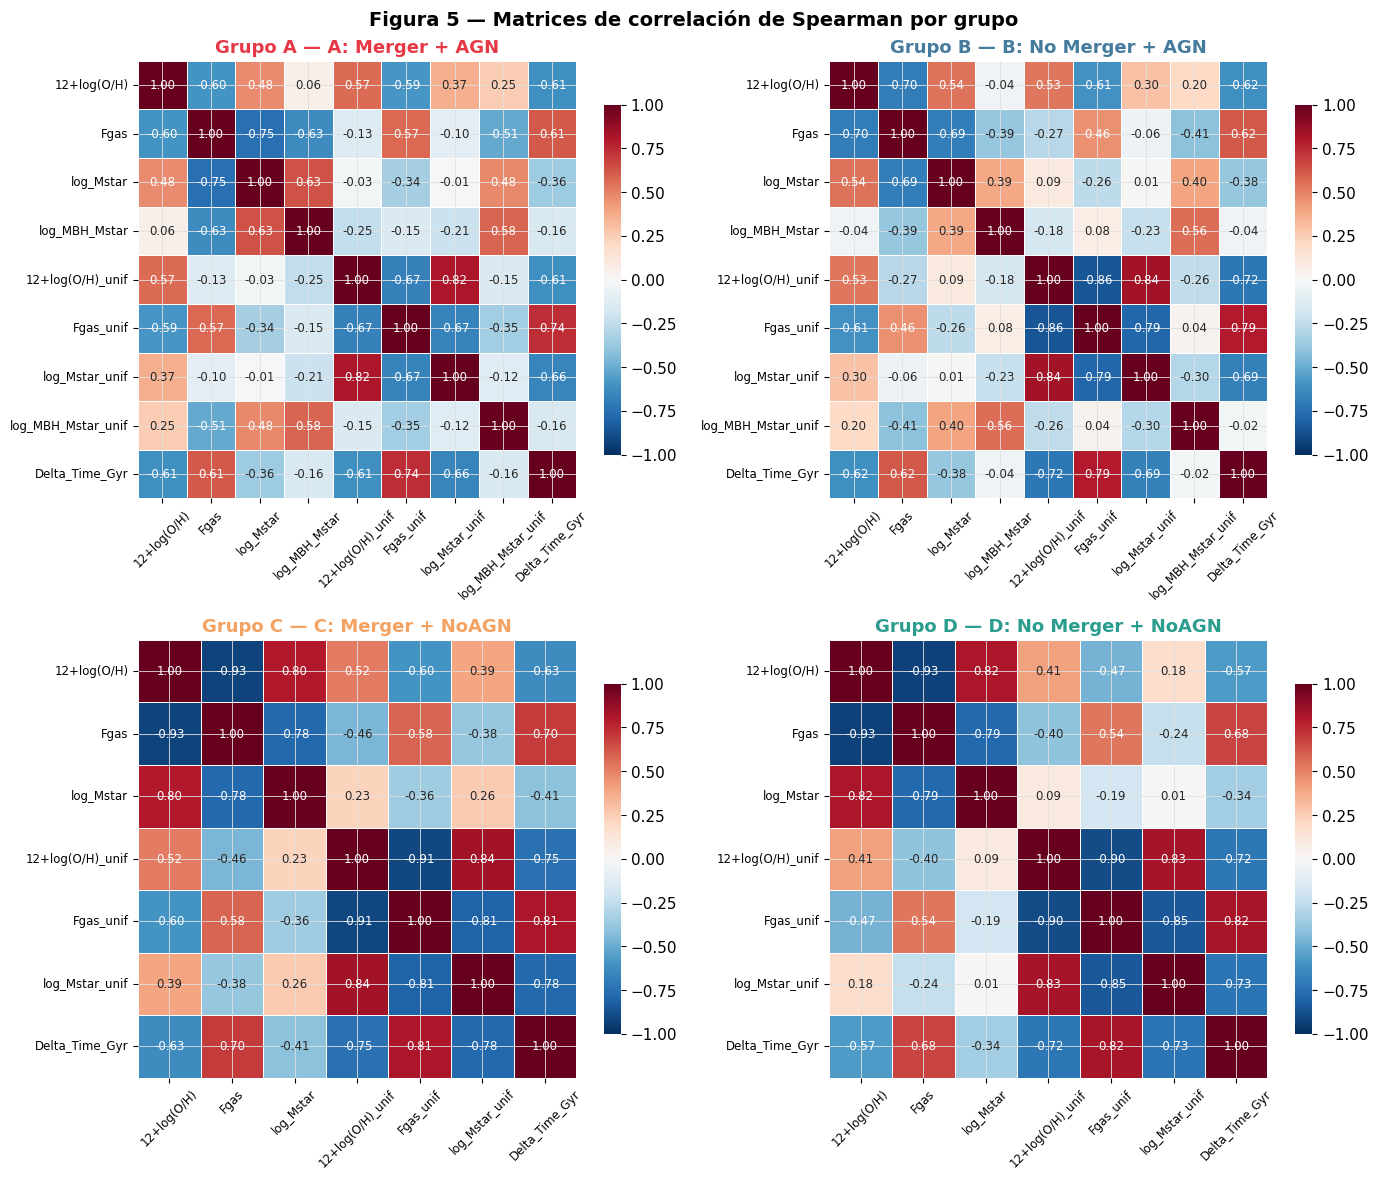

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Figura 5 — Matrices de correlación de Spearman por grupo", fontsize=14, fontweight='bold')

corr_vars_AB = ['12+log(O/H)', 'Fgas', 'log_Mstar', 'log_MBH_Mstar',
                '12+log(O/H)_unif', 'Fgas_unif', 'log_Mstar_unif','log_MBH_Mstar_unif','Delta_Time_Gyr']
corr_vars_CD = ['12+log(O/H)', 'Fgas', 'log_Mstar',
                '12+log(O/H)_unif', 'Fgas_unif', 'log_Mstar_unif','Delta_Time_Gyr']

for ax, g in zip(axes.flatten(), 'ABCD'):
    cv = corr_vars_AB if g in ['A', 'B'] else corr_vars_CD
    cv_avail = [c for c in cv if c in dfs[g].columns]
    corr_matrix = dfs[g][cv_avail].corr(method='spearman')
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(
        corr_matrix, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
        vmin=-1, vmax=1, center=0, linewidths=0.5,
        annot_kws={'size': 8.5}, mask=False,
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(f"Grupo {g} — {LABELS[g]}", color=COLORS[g], fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8.5)
    ax.tick_params(axis='y', rotation=0, labelsize=8.5)

plt.tight_layout()
#plt.savefig('/home/claude/fig5_correlaciones.png', dpi=150, bbox_inches='tight')
#plt.close()
#print("Fig 5 guardada")

## Bloque 11

In [ ]:
# FIGURA 6 — Scatter: metalicidad vs masa estelar, codificado por MBH y Fgas

## Bloque 12

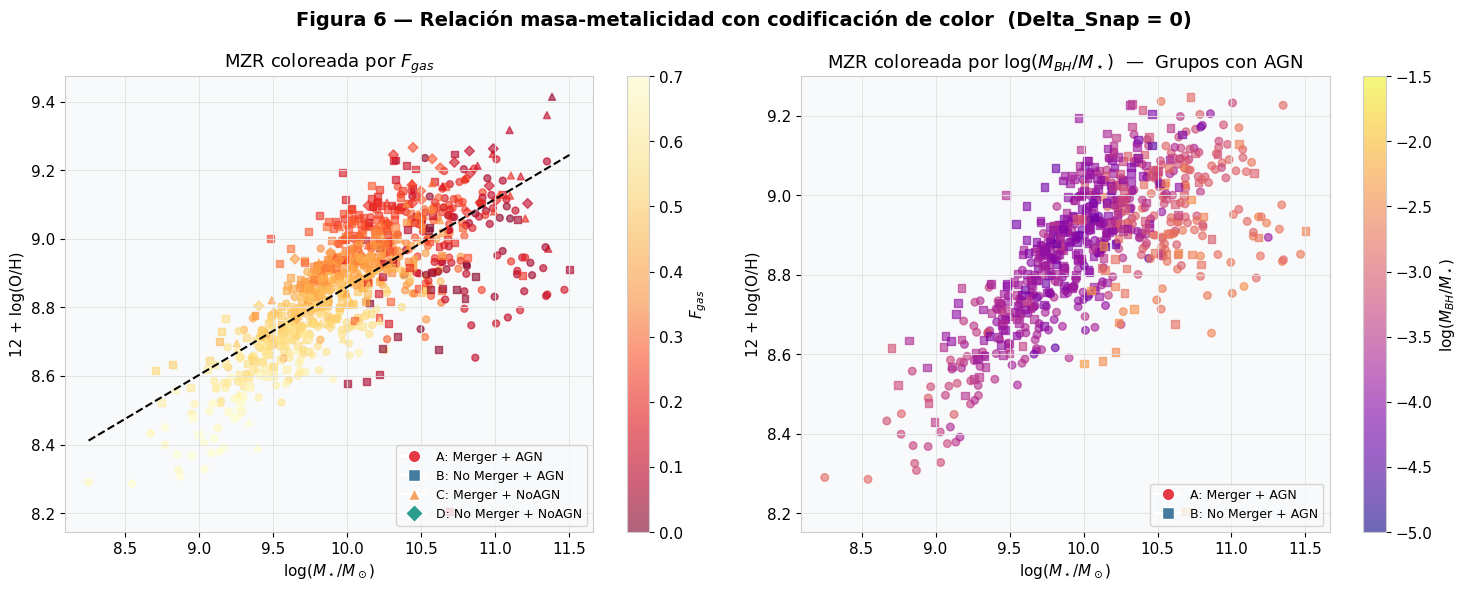

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Figura 6 — Relación masa-metalicidad con codificación de color  (Delta_Snap = 0)", fontsize=14, fontweight='bold')

# Panel izq: codificado por Fgas
ax = axes[0]
for g in 'ABCD':
    df_s = dfs[g][dfs[g]['Delta_Snap'] == 0].dropna(subset=['log_Mstar', '12+log(O/H)', 'Fgas'])
    sc = ax.scatter(df_s['log_Mstar'], df_s['12+log(O/H)'],
                    c=df_s['Fgas'], cmap='YlOrRd_r', alpha=0.6, s=25,
                    vmin=0, vmax=0.7, marker=['o','s','^','D']['ABCD'.index(g)])
plt.colorbar(sc, ax=ax, label='$F_{gas}$')
# línea de tendencia global
all_s = pd.concat([dfs[g][dfs[g]['Delta_Snap']==0][['log_Mstar','12+log(O/H)']].dropna() for g in 'ABCD'])
slope, intercept, r, p, _ = stats.linregress(all_s['log_Mstar'], all_s['12+log(O/H)'])
xfit = np.linspace(all_s['log_Mstar'].min(), all_s['log_Mstar'].max(), 100)
ax.plot(xfit, slope*xfit+intercept, 'k--', linewidth=1.5, label=f'Tendencia global (r={r:.2f})')
handles = [plt.Line2D([0],[0], marker=m, color='w', markerfacecolor=COLORS[g], markersize=9)
           for g, m in zip('ABCD', ['o','s','^','D'])]
ax.legend(handles, [LABELS[g] for g in 'ABCD'], fontsize=9, loc='lower right')
ax.set_xlabel('log($M_\\star / M_\\odot$)')
ax.set_ylabel('12 + log(O/H)')
ax.set_title("MZR coloreada por $F_{gas}$")

# Panel der: codificado por log_MBH_Mstar (sólo A y B)
ax = axes[1]
for g in ['A', 'B']:
    df_s = dfs[g][dfs[g]['Delta_Snap'] == 0].dropna(subset=['log_Mstar', '12+log(O/H)', VAR_BH])
    sc2 = ax.scatter(df_s['log_Mstar'], df_s['12+log(O/H)'],
                     c=df_s[VAR_BH], cmap='plasma', alpha=0.6, s=30,
                     vmin=-5, vmax=-1.5, marker=['o','s']['AB'.index(g)])
plt.colorbar(sc2, ax=ax, label='log($M_{BH}/M_\\star$)')
handles2 = [plt.Line2D([0],[0], marker=m, color='w', markerfacecolor=COLORS[g], markersize=9)
            for g, m in zip(['A','B'], ['o','s'])]
ax.legend(handles2, [LABELS[g] for g in ['A','B']], fontsize=9, loc='lower right')
ax.set_xlabel('log($M_\\star / M_\\odot$)')
ax.set_ylabel('12 + log(O/H)')
ax.set_title("MZR coloreada por log($M_{BH}/M_\\star$)  —  Grupos con AGN")

plt.tight_layout()
#plt.savefig('/home/claude/fig6_mzr_scatter.png', dpi=150, bbox_inches='tight')
#plt.close()
#print("Fig 6 guardada")

## Bloque 13

In [ ]:
# FIGURA 7 — Evolución de 12+log(O/H)_unif con banda de dispersión por grupo
#            (la figura más importante para el análisis bayesiano)

## Bloque 14

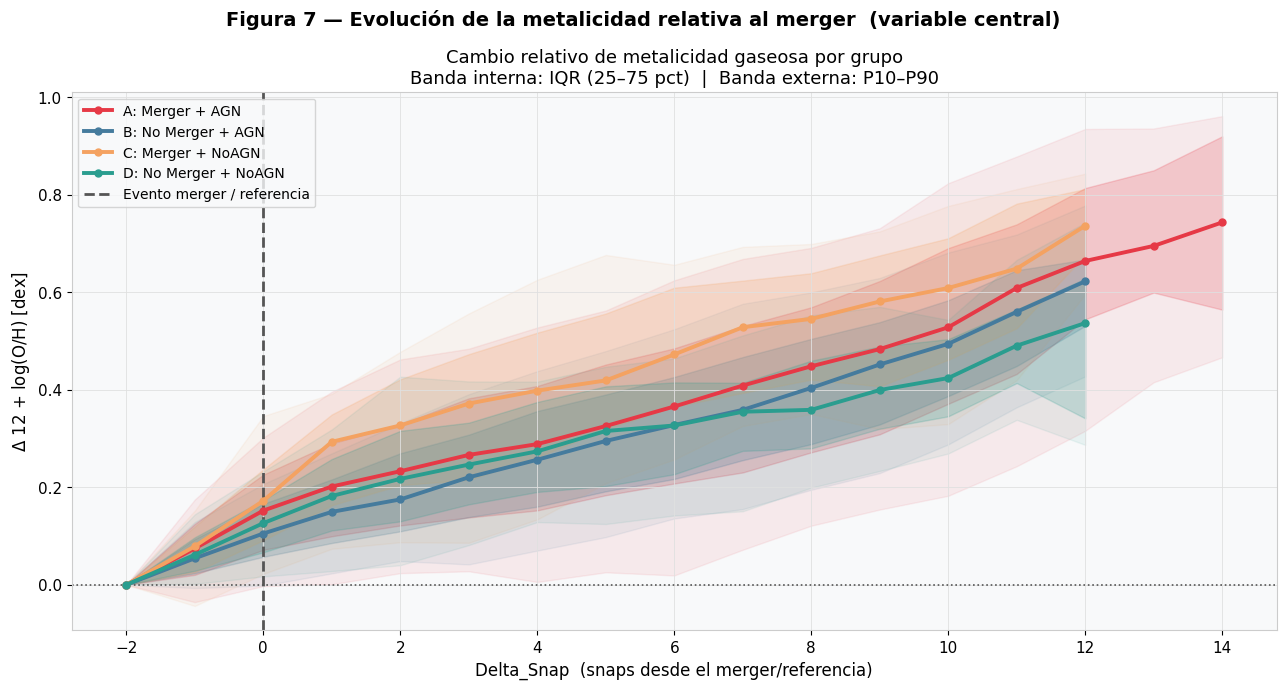

In [31]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.suptitle("Figura 7 — Evolución de la metalicidad relativa al merger  (variable central)", fontsize=14, fontweight='bold')

var = '12+log(O/H)_unif'
for g in 'ABCD':
    if var not in dfs[g].columns:
        continue
    df_g = dfs[g][['Delta_Snap', var]].dropna()
    med = df_g.groupby('Delta_Snap')[var].median()
    q10 = df_g.groupby('Delta_Snap')[var].quantile(0.10)
    q90 = df_g.groupby('Delta_Snap')[var].quantile(0.90)
    q25 = df_g.groupby('Delta_Snap')[var].quantile(0.25)
    q75 = df_g.groupby('Delta_Snap')[var].quantile(0.75)
    ax.plot(med.index, med.values, color=COLORS[g], label=LABELS[g], linewidth=2.8, marker='o', markersize=5, zorder=3)
    ax.fill_between(med.index, q25.values, q75.values, color=COLORS[g], alpha=0.20)
    ax.fill_between(med.index, q10.values, q90.values, color=COLORS[g], alpha=0.08)

ax.axvline(0, color='#555555', linestyle='--', linewidth=2, label='Evento merger / referencia')
ax.axhline(0, color='#555555', linestyle=':', linewidth=1.2)
ax.set_xlabel("Delta_Snap  (snaps desde el merger/referencia)", fontsize=12)
ax.set_ylabel(r"$\Delta$ 12 + log(O/H) [dex]", fontsize=12)
ax.set_title("Cambio relativo de metalicidad gaseosa por grupo\nBanda interna: IQR (25–75 pct)  |  Banda externa: P10–P90")
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
#plt.savefig('/home/claude/fig7_evolucion_metalicidad.png', dpi=150, bbox_inches='tight')
#plt.close()
#print("Fig 7 guardada")

## Bloque 15

In [ ]:
# FIGURA 8 — Pair plot variables uniformizadas (Grupo A)

## Bloque 16

Text(0.5, 1.01, 'Figura 8 — Pair plot de variables uniformizadas — Grupo A (Merger + AGN)')

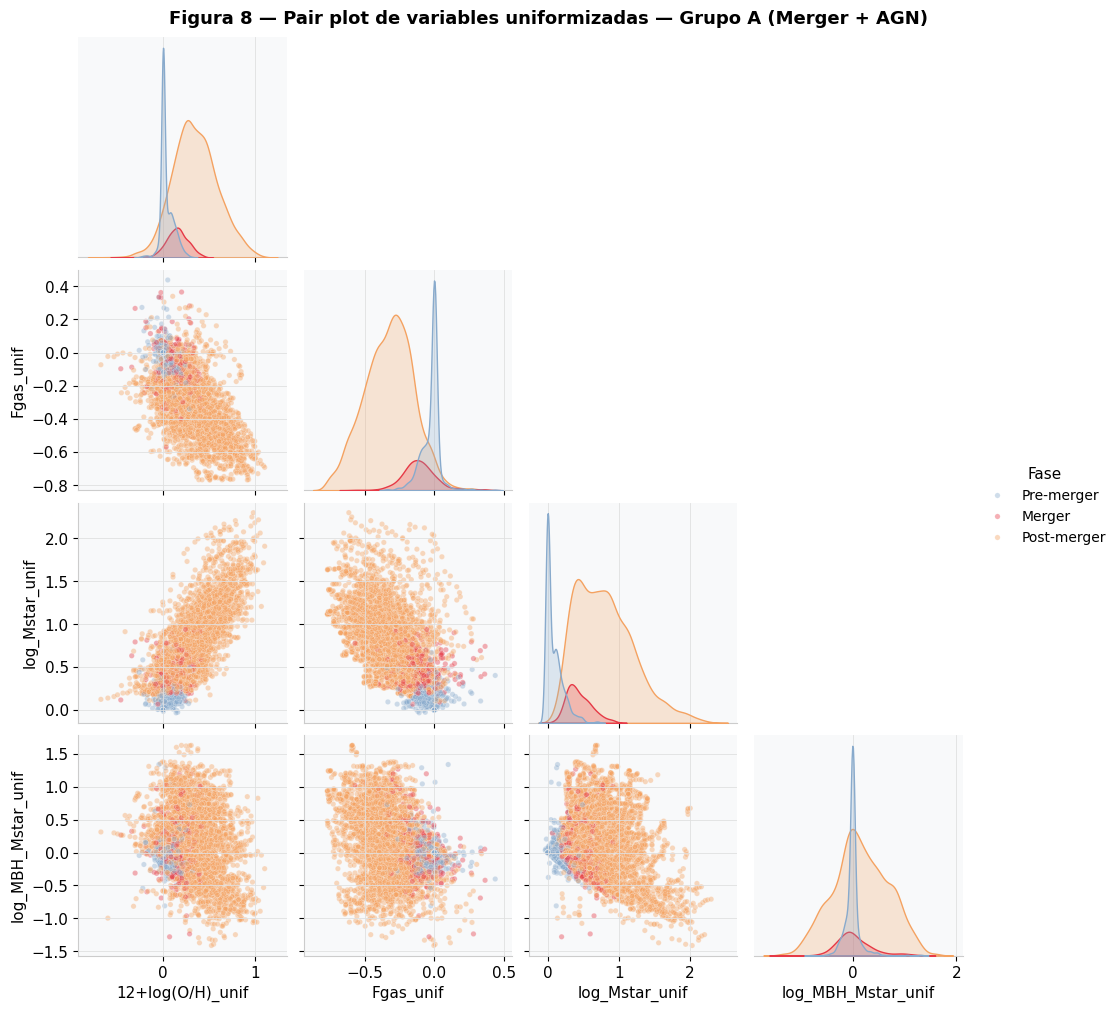

In [32]:
unif_vars_a = ['12+log(O/H)_unif', 'Fgas_unif', 'log_Mstar_unif', 'log_MBH_Mstar_unif']
df_a_pp = dfs['A'][unif_vars_a + ['Delta_Snap']].dropna()
# Colorear por Delta_Snap post vs pre merger
df_a_pp['Fase'] = df_a_pp['Delta_Snap'].apply(lambda x: 'Post-merger' if x > 0 else 'Pre-merger' if x < 0 else 'Merger')

g_pp = sns.pairplot(df_a_pp.drop(columns='Delta_Snap'), hue='Fase',
                    palette={'Pre-merger': '#88AACC', 'Merger': '#E63946', 'Post-merger': '#F4A261'},
                    plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde', corner=True)
g_pp.figure.suptitle("Figura 8 — Pair plot de variables uniformizadas — Grupo A (Merger + AGN)", y=1.01, fontsize=13, fontweight='bold')
#g_pp.figure.savefig('/home/claude/fig8_pairplot_A.png', dpi=150, bbox_inches='tight')
#plt.close()
#print("Fig 8 guardada")

## Bloque 17

In [ ]:
# TABLA RESUMEN — estadísticas por grupo en Delta_Snap == 0

## Bloque 18

In [ ]:
print("\n=== Tabla resumen estadísticas en Delta_Snap = 0 ===")
rows = []
for g in 'ABCD':
    df_s = dfs[g][dfs[g]['Delta_Snap'] == 0]
    row = {'Grupo': g, 'N': len(df_s)}
    for var in ['12+log(O/H)_unif', 'Fgas_unif', 'log_Mstar_unif']:
        if var in df_s.columns:
            row[f'{var}_median'] = round(df_s[var].median(), 3)
            row[f'{var}_std']    = round(df_s[var].std(), 3)
    if VAR_BH in df_s.columns:
        row[f'{VAR_BH}_median'] = round(df_s[VAR_BH].median(), 3)
    rows.append(row)
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

print("\n=== Tests de Kruskal-Wallis (12+log(O/H)_unif en Delta_Snap = 0) ===")
grupos_vals = [dfs[g][dfs[g]['Delta_Snap']==0]['12+log(O/H)_unif'].dropna().values for g in 'ABCD']
stat, p = stats.kruskal(*grupos_vals)
print(f"  H = {stat:.3f},  p-value = {p:.4e}")
if p < 0.05:
    print("  → Diferencias significativas entre grupos (p < 0.05)")
    print("  → Tests pairwise Mann-Whitney U:")
    grupos_list = list('ABCD')
    for i in range(len(grupos_list)):
        for j in range(i+1, len(grupos_list)):
            gi, gj = grupos_list[i], grupos_list[j]
            u, pu = stats.mannwhitneyu(
                dfs[gi][dfs[gi]['Delta_Snap']== 0]['12+log(O/H)_unif'].dropna(),
                dfs[gj][dfs[gj]['Delta_Snap']== 0]['12+log(O/H)_unif'].dropna(),
                alternative='two-sided'
            )
            sig = '***' if pu < 0.001 else '**' if pu < 0.01 else '*' if pu < 0.05 else 'n.s.'
            print(f"    {gi} vs {gj}: U={u:.0f}, p={pu:.4e} {sig}")

#print("\nTodas las figuras guardadas en /home/claude/")


=== Tabla resumen estadísticas en Delta_Snap = 0 ===
Grupo   N  12+log(O/H)_unif_median  12+log(O/H)_unif_std  Fgas_unif_median  Fgas_unif_std  log_Mstar_unif_median  log_Mstar_unif_std  log_MBH_Mstar_median
    A 393                    0.152                 0.125            -0.115          0.122                  0.407               0.172                -3.513
    B 339                    0.105                 0.091            -0.080          0.076                  0.171               0.115                -3.774
    C  78                    0.172                 0.130            -0.104          0.102                  0.426               0.136                   NaN
    D  60                    0.126                 0.093            -0.086          0.059                  0.204               0.102                   NaN

=== Tests de Kruskal-Wallis (12+log(O/H) en Delta_Snap = 0) ===
  H = 43.747,  p-value = 1.7083e-09
  → Diferencias significativas entre grupos (p < 0.05)
  → Tests pairw

In [ ]:
print("\n=== Tabla resumen estadísticas en Delta_Snap = 0 ===")
rows = []
for g in 'ABCD':
    df_s = dfs[g][dfs[g]['Delta_Snap'] == 0]
    row = {'Grupo': g, 'N': len(df_s)}
    for var in ['12+log(O/H)_unif', 'Fgas_unif', 'log_Mstar_unif']:
        if var in df_s.columns:
            row[f'{var}_median'] = round(df_s[var].median(), 3)
            row[f'{var}_std']    = round(df_s[var].std(), 3)
    if VAR_BH in df_s.columns:
        row[f'{VAR_BH}_median'] = round(df_s[VAR_BH].median(), 3)
    rows.append(row)
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

print("\n=== Tests de Kruskal-Wallis (12+log(O/H)_unif en Delta_Snap = 0) ===")
grupos_vals = [dfs[g][dfs[g]['Delta_Snap']==0]['12+log(O/H)_unif'].dropna().values for g in 'ABCD']
stat, p = stats.kruskal(*grupos_vals)
print(f"  H = {stat:.3f},  p-value = {p:.4e}")
if p < 0.05:
    print("  → Diferencias significativas entre grupos (p < 0.05)")
    print("  → Tests pairwise Mann-Whitney U:")
    grupos_list = list('ABCD')
    for i in range(len(grupos_list)):
        for j in range(i+1, len(grupos_list)):
            gi, gj = grupos_list[i], grupos_list[j]
            u, pu = stats.mannwhitneyu(
                dfs[gi][dfs[gi]['Delta_Snap']==0]['12+log(O/H)_unif'].dropna(),
                dfs[gj][dfs[gj]['Delta_Snap']==0]['12+log(O/H)_unif'].dropna(),
                alternative='two-sided'
            )
            sig = '***' if pu < 0.001 else '**' if pu < 0.01 else '*' if pu < 0.05 else 'n.s.'
            print(f"    {gi} vs {gj}: U={u:.0f}, p={pu:.4e} {sig}")


=== Tabla resumen estadísticas en Delta_Snap = 0 ===
Grupo   N  12+log(O/H)_unif_median  12+log(O/H)_unif_std  Fgas_unif_median  Fgas_unif_std  log_Mstar_unif_median  log_Mstar_unif_std  log_MBH_Mstar_median
    A 393                    0.152                 0.125            -0.115          0.122                  0.407               0.172                -3.513
    B 339                    0.105                 0.091            -0.080          0.076                  0.171               0.115                -3.774
    C  78                    0.172                 0.130            -0.104          0.102                  0.426               0.136                   NaN
    D  60                    0.126                 0.093            -0.086          0.059                  0.204               0.102                   NaN

=== Tests de Kruskal-Wallis (12+log(O/H) en Delta_Snap = 0) ===
  H = 43.747,  p-value = 1.7083e-09
  → Diferencias significativas entre grupos (p < 0.05)
  → Tests pairw

In [40]:
dfs['A'].columns

Index(['RootGalaxyID', 'GalaxyID', 'SnapNum', 'Snap_Major_Merger',
       'Delta_Snap', 'Delta_Time_Gyr', '12+log(O/H)_unif', 'Fgas_unif',
       'log_Mstar_unif', 'log_MBH_Mstar_unif', '12+log(O/H)', 'Fgas',
       'log_Mstar', 'log_MBH_Mstar', 'Grupo'],
      dtype='str')